## **1ª Etapa**: Análise Exploratória e Limpeza do Dataset ##

[Link do Dataset no Kaggle](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset)

In [178]:
import pandas as pd
import ast
import numpy as np

df = pd.read_csv('archive/movies_metadata.csv')

Análise Exploratória do Dataset

In [179]:
# Vamos começar conhecendo melhor as features (variáveis independentes) que possuímos
df.head(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45463 non-null  bool   
 1   belongs_to_collection  4491 non-null   object 
 2   budget                 45463 non-null  int64  
 3   genres                 45463 non-null  object 
 4   homepage               7779 non-null   object 
 5   id                     45463 non-null  int64  
 6   imdb_id                45446 non-null  object 
 7   original_language      45452 non-null  object 
 8   original_title         45463 non-null  object 
 9   overview               44509 non-null  object 
 10  popularity             45463 non-null  float64
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [180]:
df.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92


Primeiramente, vamos eliminar algumas variáveis que não serão aplicadas ao modelo. As selecionadas foram as seguintes:

- homepage: Página de publicidade do filme
- poster_path: ID do banner do filme (Localizável em: image.tmdb.org/t/p/w185/ID)
- status: Se já foi lançado ou não (Como o Dataset é de 2017, todos os filmes já devem ter sido lançados)
- video: 

In [181]:
df.drop(['homepage', 'poster_path', 'status', 'video', 'production_companies', 'tagline'], axis=1, inplace= True)

In [182]:
df.head(3)

,adult,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Jumanji,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Grumpier Old Men,6.5,92


Como podemos observar, as variáveis a seguir foram categorizadas como object, quando na realidade deveriam ser numéricas ou booleanos
- adult: Booleano (False/True)
- budget: Numérico (Dinheiro)
- release_date: Numérico (Data de Lançamento)
- popularity: Numérico ()

In [183]:
# Conferindo se há valores além de "True" e "False" na coluna
df['adult'].unique()

# Substituindo as strings "True" e "False" pelos valores booleanos
df['adult'] = df['adult'] == 'True'

In [184]:
# Analisando quais são os caracteres presentes dentro da coluna budget.
df['budget'].astype(str).apply(list).explode().unique()

# Como podemos observar no Output, a coluna contém somente numerais e nenhum ponto (.), o que indica que todos os valores são números inteiros
# Isso significa que podemos seguir com a conversão para integer diretamente
df['budget'] = df['budget'].astype('Int64')

In [185]:
df['release_date'] = pd.to_datetime(df['release_date'])

In [186]:
df.head(2)

,adult,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Jumanji,6.9,2413


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45463 non-null  bool          
 1   belongs_to_collection  4491 non-null   object        
 2   budget                 45463 non-null  Int64         
 3   genres                 45463 non-null  object        
 4   id                     45463 non-null  int64         
 5   imdb_id                45446 non-null  object        
 6   original_language      45452 non-null  object        
 7   original_title         45463 non-null  object        
 8   overview               44509 non-null  object        
 9   popularity             45463 non-null  float64       
 10  production_countries   45463 non-null  object        
 11  release_date           45379 non-null  datetime64[ns]
 12  revenue                45463 non-null  int64         
 13  r

In [188]:
# Para facilitar a visualização da tipagem dos dados, vamos reorganizar a tabela
nova_ordem_colunas = [
    # Booleana
    'adult',

    # Numéricas (Inteiros)
    'id', 'budget', 'revenue', 'vote_count',

    # Numéricas (Decimais / Floats)
    'popularity', 'runtime', 'vote_average',

    # Data
    'release_date',

    # Texto / Objeto (Descritivas)
    'title', 'original_title', 'overview',

    # Texto / Objeto (Listas/Metadados)
    'genres', 'belongs_to_collection', 'production_countries', 'spoken_languages',

    # Texto / Objeto (IDs/Código)
    'imdb_id', 'original_language'
]

df = df[nova_ordem_colunas]
df.head(5)

,adult,id,budget,revenue,vote_count,popularity,runtime,vote_average,release_date,title,original_title,overview,genres,belongs_to_collection,production_countries,spoken_languages,imdb_id,original_language
0,False,862,30000000,373554033,5415,21.946943,81.0,7.7,1995-10-30,Toy Story,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","{'id': 10194, 'name': 'Toy Story Collection', ...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0114709,en
1,False,8844,65000000,262797249,2413,17.015539,104.0,6.9,1995-12-15,Jumanji,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",tt0113497,en
2,False,15602,0,0,92,11.712900,101.0,6.5,1995-12-22,Grumpier Old Men,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","{'id': 119050, 'name': 'Grumpy Old Men Collect...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0113228,en
3,False,31357,16000000,81452156,34,3.859495,127.0,6.1,1995-12-22,Waiting to Exhale,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0114885,en
4,False,11862,0,76578911,173,8.387519,106.0,5.7,1995-02-10,Father of the Bride Part II,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]","{'id': 96871, 'name': 'Father of the Bride Col...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0113041,en


In [189]:
# Por último, a coluna belongs_to_collection possui 90% dos seus valores como NaN. Isso será um problema no treinamento do modelo.
# Para reverter isso, vamos desserializar os dados, convertendo todos para dicionários, incluindo os valores nulos
df['belongs_to_collection'] = df['belongs_to_collection'].apply(
    lambda x: x if pd.notna(x) else {} # Os valores NaN serão convertidos em dicionários vazios {}
)

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45463 non-null  bool          
 1   id                     45463 non-null  int64         
 2   budget                 45463 non-null  Int64         
 3   revenue                45463 non-null  int64         
 4   vote_count             45463 non-null  int64         
 5   popularity             45463 non-null  float64       
 6   runtime                45206 non-null  float64       
 7   vote_average           45463 non-null  float64       
 8   release_date           45379 non-null  datetime64[ns]
 9   title                  45463 non-null  object        
 10  original_title         45463 non-null  object        
 11  overview               44509 non-null  object        
 12  genres                 45463 non-null  object        
 13  b

## **2ª Etapa**: Segunda Análise Exploratória mais aprofundada ##

In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # O Seaborn facilita a criação de gráficos estatísticos e usa o Matplotlib por baixo dos panos

# Configuração básica para visualização (opcional)
sns.set_style("whitegrid") 
plt.rcParams['figure.figsize'] = (10, 6) # Define um tamanho padrão para os gráficos

Vamos usar um histograma para visualizar qual a duração mais comuns dos filmes presentes no Dataset

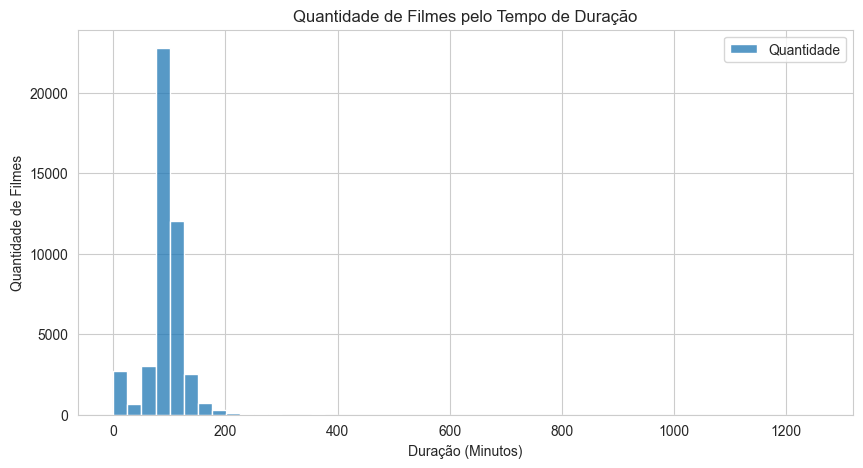

In [192]:
# Histograma: Mostra a distribuição de uma única variável
plt.figure(figsize=(10, 5))
sns.histplot(df['runtime'].dropna(), kde=False, bins=50) 
# Usamos dropna() para ignorar os NaNs
# kde=True adiciona uma estimativa da densidade (suaviza a curva)
plt.title('Quantidade de Filmes pelo Tempo de Duração')
plt.xlabel('Duração (Minutos)')
plt.ylabel('Quantidade de Filmes')
plt.legend(['Quantidade', 'Tempo'])
plt.show()

In [193]:
# Aqui, como temos poucas linhas NaN (cerca de 200), vamos removê-las do Dataset
df = df.dropna(subset=['runtime'])

# Vamos definir uma função que atribua uma categoria de acordo com a duração do filme
def categorizar_duracao(runtime):
    if runtime < 15:
        return "Very Short"
    
    elif 15 <= runtime < 60: # < 1hr
        return "Short"
    
    elif 60 <= runtime < 90: # De 1 a 1,5
        return "Short-Medium"
    
    elif 90 <= runtime < 120: # De 1,5 a 2
        return "Medium-Long"
    
    elif 120 <= runtime < 180: # De 2 a 3
        return "Long"
    
    elif 180 <= runtime: # > 3
        return "Very Long"
    
# Aqui aplicamos a função sobre a coluna runtime, criando a nova coluna Categoria de Duração
df['runtime_category'] = df['runtime'].apply(categorizar_duracao)

runtime_category
Medium-Long     24155
Short-Medium    11519
Long             5004
Very Short       2392
Short            1540
Very Long         596
Name: count, dtype: int64


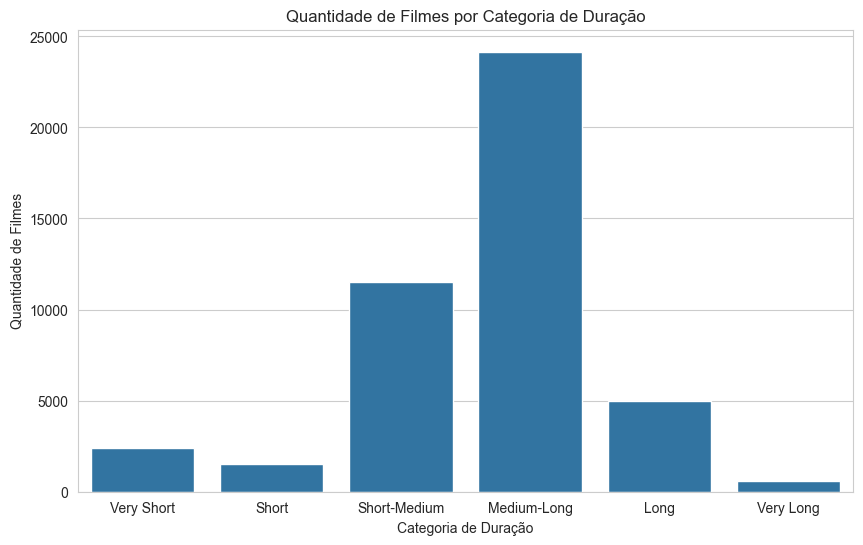

In [194]:
# Imprimir uma tabelinha com as contagens de cada categoria
print(df['runtime_category'].value_counts())

# Como estamos trabalhando com variáveis categóricas agora, vamos usar uma countplot
sns.countplot(data=df, x='runtime_category', order=['Very Short', 'Short', 'Short-Medium', 'Medium-Long', 'Long', 'Very Long' ])
plt.title('Quantidade de Filmes por Categoria de Duração')
plt.xlabel('Categoria de Duração')
plt.ylabel('Quantidade de Filmes')

plt.show()

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45206 entries, 0 to 45462
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45206 non-null  bool          
 1   id                     45206 non-null  int64         
 2   budget                 45206 non-null  Int64         
 3   revenue                45206 non-null  int64         
 4   vote_count             45206 non-null  int64         
 5   popularity             45206 non-null  float64       
 6   runtime                45206 non-null  float64       
 7   vote_average           45206 non-null  float64       
 8   release_date           45133 non-null  datetime64[ns]
 9   title                  45206 non-null  object        
 10  original_title         45206 non-null  object        
 11  overview               44509 non-null  object        
 12  genres                 45206 non-null  object        
 13  belong

### Analisando e entendendo a variável popularity. ###
Conforme é explicado no próprio [site](https://developer.themoviedb.org/docs/popularity-and-trending) da The Movie Database, a métrica de popularidade é um indicador dinâmico que reflete: quantidade de votos; quantas vezes o filme foi favoritado; quantas vezes foi adicionado à "Watchlist"

In [196]:
df[['original_title','popularity']].sort_values('popularity', ascending=False)

,original_title,popularity
30698,Minions,547.488298
33354,Wonder Woman,294.337037
42219,Beauty and the Beast,287.253654
43641,Baby Driver,228.032744
24454,Big Hero 6,213.849907
...,...,...
20102,Electile Dysfunction: Inside the Business of A...,0.000000
24415,Une partie de plaisir,0.000000
16836,Das Experiment 770 - Gebären auf Befehl,0.000000
45335,The Land Where the Blues Began,0.000000


Por outro lado, a variável vote_average, que representa a nota média que o filme recebeu, também é um indicador interessante para avaliar o engajamento do telespectador.
Vamos tentar observar uma correlação entre essas duas variáveis a seguir.

In [197]:
df[['original_title','vote_average']].sort_values('vote_average', ascending=False)

,original_title,vote_average
27172,بید و باد,10.0
24213,200 Cartas,10.0
16681,The Misadventures of Margaret,10.0
36075,Looking for Grace,10.0
41801,Bella Vita,10.0
...,...,...
45270,Tragedy in a Temporary Town,0.0
45271,Carole King: Natural Woman,0.0
45279,Dom wariatów,0.0
3460,"Jails, Hospitals & Hip-Hop",0.0


Porcentagem do Dataset Analisado: 0.93


Text(0, 0.5, 'Nota Média (0 a 10)')

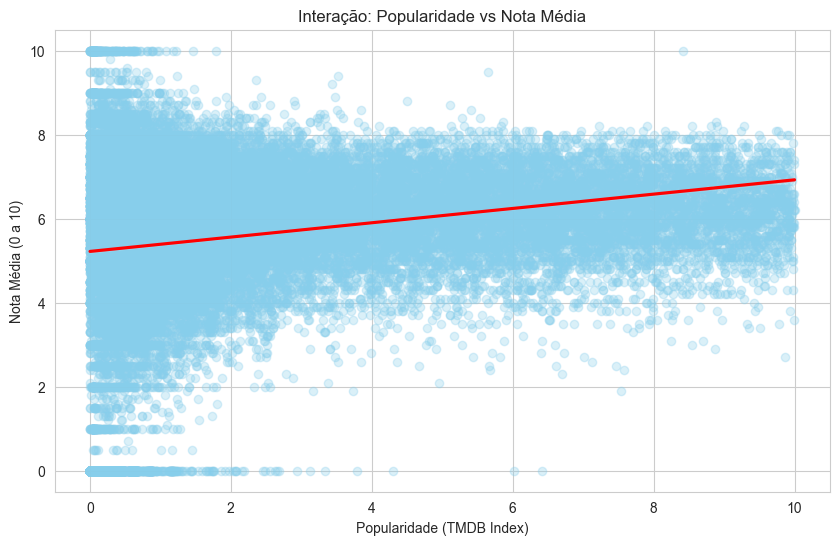

In [198]:
df_analise = df.loc[df['popularity'] < 10]

pct_dataset_analisado = round(len(df_analise)/len(df),2)

print('Porcentagem do Dataset Analisado:',pct_dataset_analisado)



sns.regplot(data=df_analise, x='popularity', y='vote_average',

            scatter_kws={'alpha':0.3, 'color':'skyblue'},

            line_kws={'color':'red'})



plt.title('Interação: Popularidade vs Nota Média')

plt.xlabel('Popularidade (TMDB Index)')

plt.ylabel('Nota Média (0 a 10)')



Porcentagem do Dataset Analisado: 0.21743
Filmes incluidos no filtro: 9829/45206


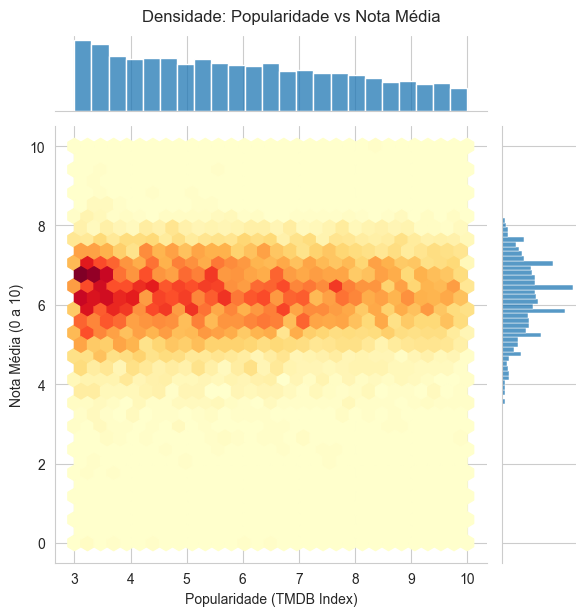

In [199]:
# Filtro simples
df_analise = df.loc[(df['popularity'] < 10) & (df['popularity'] > 3)]

# df_analise = df.loc[df['popularity'] < 10]

# df_analise = df.loc[df['popularity'] > 3]

pct_dataset_analisado = round(len(df_analise)/len(df),5)
print('Porcentagem do Dataset Analisado:',pct_dataset_analisado)
print('Filmes incluidos no filtro:', f"{len(df_analise)}"+f"/{len(df)}")

# O jointplot cria o gráfico de dispersão com "hexágonos" de calor
# e ainda adiciona histogramas nas bordas para ver o acúmulo nos eixos
g = sns.jointplot(data=df_analise, x='popularity', y='vote_average', 
                  kind='hex', cmap='YlOrRd', gridsize=30)

# Ajustando títulos e nomes de eixos
g.fig.suptitle('Densidade: Popularidade vs Nota Média', y=1.02)
g.set_axis_labels('Popularidade (TMDB Index)', 'Nota Média (0 a 10)')

plt.show()

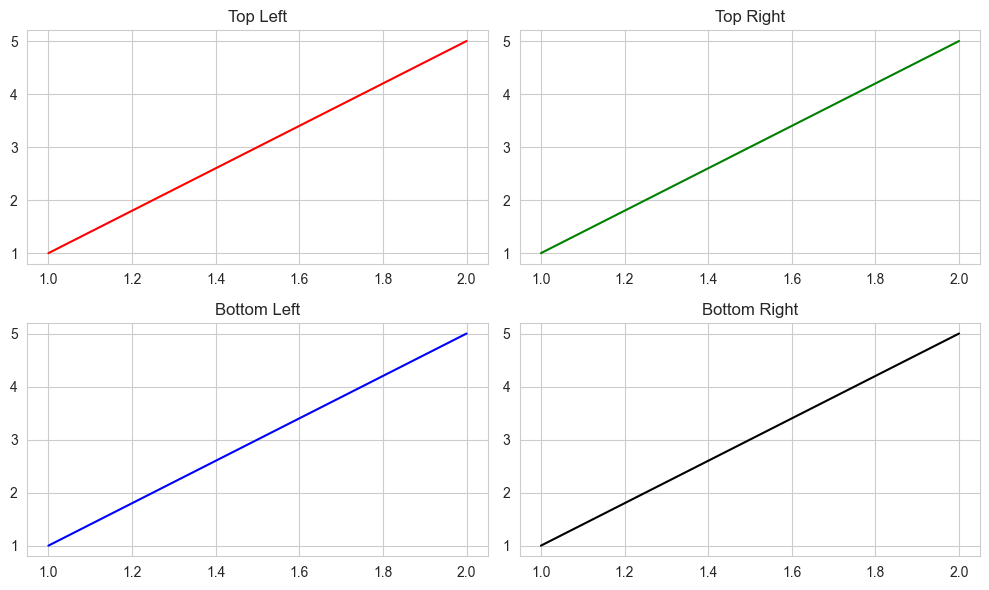

In [200]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

# Plot data on specific subplots using array indexing [row, column]
axs[0, 0].plot([1, 2], [1, 5], 'r-')
axs[0, 0].set_title('Top Left')

axs[0, 1].plot([1, 2], [1, 5], 'g-')
axs[0, 1].set_title('Top Right')

axs[1, 0].plot([1, 2], [1, 5], 'b-')
axs[1, 0].set_title('Bottom Left')

axs[1, 1].plot([1, 2], [1, 5], 'k-')
axs[1, 1].set_title('Bottom Right')

# Optional: Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()


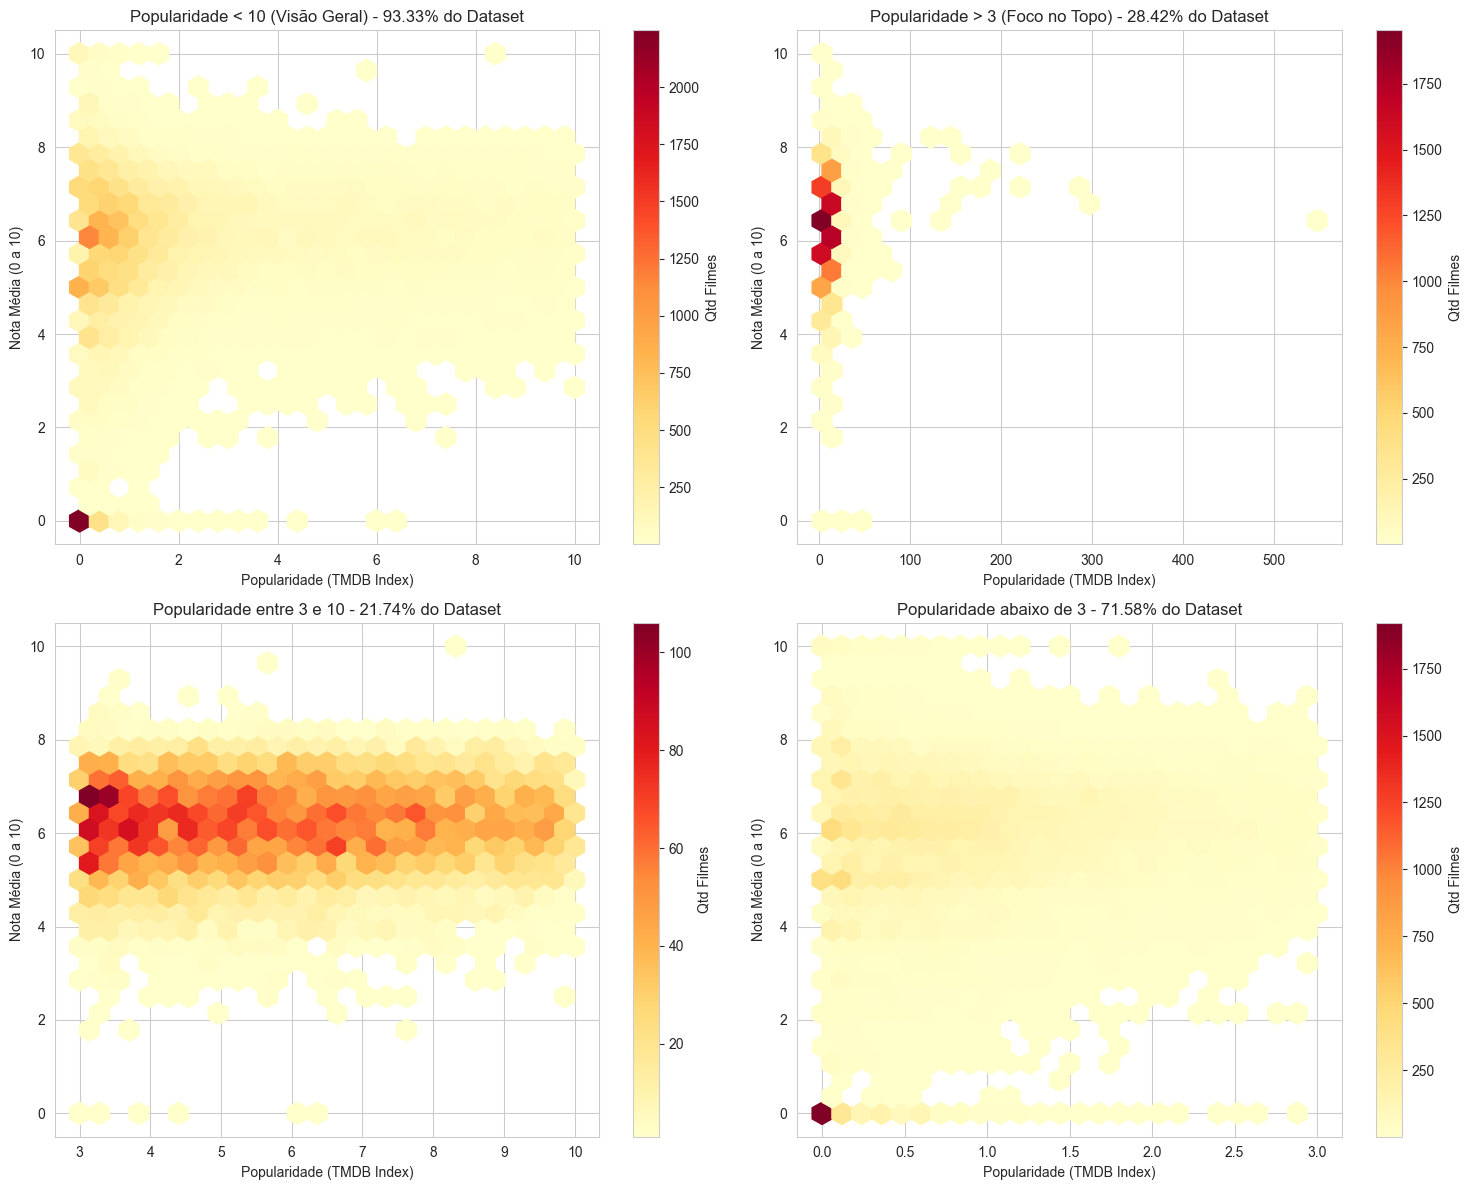

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração da figura (2x2)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# --- 1. Filtro: Popularidade < 10 ---
df_1 = df.loc[df['popularity'] < 10]
hb1 = axs[0, 0].hexbin(df_1['popularity'], df_1['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[0, 0].set_title(f"Popularidade < 10 (Visão Geral) - {round(len(df_1)/len(df)*100, 2)}% do Dataset")
plt.colorbar(hb1, ax=axs[0, 0], label='Qtd Filmes')

# --- 2. Filtro: Popularidade > 3 ---
df_2 = df.loc[df['popularity'] > 3]
hb2 = axs[0, 1].hexbin(df_2['popularity'], df_2['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[0, 1].set_title(f"Popularidade > 3 (Foco no Topo) - {round(len(df_2)/len(df)*100, 2)}% do Dataset")
plt.colorbar(hb2, ax=axs[0, 1], label='Qtd Filmes')

# --- 3. Filtro: Entre 3 e 10 ---
df_3 = df.loc[(df['popularity'] < 10) & (df['popularity'] > 3)]
hb3 = axs[1, 0].hexbin(df_3['popularity'], df_3['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[1, 0].set_title(f"Popularidade entre 3 e 10 - {round(len(df_3)/len(df)*100, 2)}% do Dataset")
plt.colorbar(hb3, ax=axs[1, 0], label='Qtd Filmes')

# --- 3. Filtro: Entre 3 e 10 ---
df_4 = df.loc[df['popularity'] < 3]
hb4 = axs[1, 1].hexbin(df_4['popularity'], df_4['vote_average'], gridsize=25, cmap='YlOrRd', mincnt=1)
axs[1, 1].set_title(f"Popularidade abaixo de 3 - {round(len(df_4)/len(df)*100, 2)}% do Dataset")
plt.colorbar(hb4, ax=axs[1, 1], label='Qtd Filmes')

# # --- 4. Limpeza do quadrante vazio ---
# axs[1, 1].axis('off')

# Padronização de nomes de eixos usando o flat
for ax in axs.flat:
    if ax.axison:
        ax.set_xlabel('Popularidade (TMDB Index)')
        ax.set_ylabel('Nota Média (0 a 10)')

plt.tight_layout()
plt.show()